# **Mount Drive**

# **2024 Failure Share Inequality Plot Weighted SVI**

In [3]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib import pyplot as plt
import seaborn as sns
from glob import glob

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)


In [ ]:
ffail = '<DATA_ROOT>/crop_failure_modified/crops_failure_0595.csv'
df_fail = pd.read_csv(ffail)
df_fail = df_fail.drop(columns=['Unnamed: 0'])
df_fail = df_fail.sort_values(by=['FIPS'])
# cond1 = df_fail['year']>2011
cond2 = df_fail['Planted Acres'] > 0
df_fail = df_fail[cond2]
df_fail['fail_share'] = df_fail['Failed Acres'] /  df_fail['Planted Acres']
df_fail = df_fail[df_fail.fail_share < 1]
# df_fail = df_fail[df_fail.fail_share > 0]
# formatted_numbers = [str(n).zfill(5) for n in df_fail['FIPS'].values]
# df_fail['FIPS'] = formatted_numbers
df_fail = df_fail[['FIPS','year','Crop','Irrigation Practice','Planted Acres','fail_share']]
df_fail

In [ ]:
svi_path = '<DATA_ROOT>/SVI_weightedCrop_Final/*.csv'
files = glob(svi_path)
list_df = []
for fsvi in files:
  crop = fsvi.split('/')[-1][4:-4]
  df_svi = pd.read_csv(fsvi)
  svi_cols = ['STCNTY','YEAR','RPL_THEME1','RPL_THEME2','RPL_THEME3','RPL_THEME4','RPL_THEMES']
  df_svi = df_svi[svi_cols].dropna()
  df_svi = df_svi.rename(columns={'STCNTY':'FIPS','YEAR':'year'})

  df_svi = df_svi.set_index(['FIPS','year'])
  bins = list(np.arange(0,101,5)/100)
  labels = list(np.arange(0,100,5)/100)
  df_svi_cat = df_svi.apply(lambda x: pd.cut(x, bins=bins, labels=labels), axis=0)
  df_svi_cat = df_svi_cat.reset_index()

  df_svi_cat['Crop'] = crop
  list_df.append(df_svi_cat)

df_svi = pd.concat(list_df,ignore_index=True)
df_merge = pd.merge(df_fail,df_svi,on=['FIPS','year','Crop'])
df_merge

In [ ]:
theme = 'RPL_THEMES'
irig_type = 'Irrigated' #'Irrigated' #'ALL-Irrigation'

cond1 = df_merge['Irrigation Practice'] == 'I'
df_CropAreaTheme = df_merge[cond1].groupby(['Crop',theme , 'year'])['Planted Acres'].sum().reset_index()
# df_CropAreaTheme = df_CropAreaTheme.groupby(['Crop',theme])['Planted Acres'].sum().reset_index()
df_CropAreaTheme = df_CropAreaTheme.groupby(['Crop',theme])['Planted Acres'].mean().reset_index()
df_CropAreaTheme = df_CropAreaTheme.pivot(index=theme,columns='Crop',values='Planted Acres')

cond1 = df_merge['Irrigation Practice'] == 'I'
df_CropFailTheme = df_merge[cond1].groupby(['Crop',theme]).mean().reset_index()
df_CropFailTheme = df_CropFailTheme.pivot(index=theme,columns='Crop',values='fail_share')


import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
import numpy as np

crops = ['CORN', 'COTTON', 'OATS', 'SORGHUM', 'SOYBEANS', 'WHEAT', 'BARLEY', 'HAY']
fig, axes = plt.subplots(nrows=4, ncols=2,figsize=(16,10),dpi=1200)
i = 0

for ax_row in axes:
    for ax in ax_row:

        ws = 4
        sns.lineplot(data=df_CropAreaTheme.rolling(window=ws, min_periods=1).mean(),
                     x=df_CropAreaTheme.index, y=crops[i], color='#3ec429', ax=ax)
        ax.fill_between(df_CropAreaTheme.index, 0,
                        df_CropAreaTheme[crops[i]].rolling(window=ws, min_periods=1).mean(),
                        color='#3ec429', alpha=0.3)

        ax_twin = ax.twinx()
        sns.lineplot(data=df_CropFailTheme.rolling(window=ws, min_periods=1).mean(),
                     x=df_CropFailTheme.index, y=crops[i], color='#e69447', ax=ax_twin)
        ax_twin.fill_between(df_CropFailTheme.index, 0,
                             df_CropFailTheme[crops[i]].rolling(window=ws, min_periods=1).mean(),
                             color='#e69447', alpha=0.3)

        ax.set_title(crops[i])
        ax.set_xticks([])
        # ax.set_yticks([])
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_ylim(0)
        ax.set_xlim(0,1)


        if i > 5:
          ax.set_xticks(list(np.arange(0,11,2)/10))
          ax.set_xticklabels(list(np.arange(0,11,2)/10), fontsize=16)


        # ax_twin.set_yticks([])
        ax_twin.set_xlabel('')
        ax_twin.set_ylabel('')
        ax_twin.set_ylim(0)
        ax_twin.set_xlim(0,1)

        i += 1

plt.suptitle(f'{irig_type} {theme}',fontsize=14)
out_path = '<DATA_ROOT>/Final_Exports_2024/20240214-Section2/20240214-InequlityPlot_FailurePlant_wSVI/'
plt.savefig(out_path + 'InequlityPlot_FailurePlant_' + theme + '_' + "".join(irig_type.split()) + '.png' , dpi=1200)
plt.tight_layout()
# plt.show()


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
import numpy as np

# for theme in ['RPL_THEME1','RPL_THEME2','RPL_THEME3','RPL_THEME4','RPL_THEMES']:
for theme in ['RPL_THEME4','RPL_THEMES']:
  for irig_type in ['Irrigated', 'Rainfed', 'ALL-Irrigation']:

    print(theme , irig_type)

    irig_val = 'ALL'
    if irig_type == 'Irrigated':  irig_val = 'I'
    if irig_type == 'Rainfed':  irig_val = 'N'

    cond1 = df_merge['Irrigation Practice'] == irig_val
    df_CropAreaTheme = df_merge[cond1].groupby(['Crop',theme , 'year'])['Planted Acres'].sum().reset_index()
    # df_CropAreaTheme = df_CropAreaTheme.groupby(['Crop',theme])['Planted Acres'].sum().reset_index()
    df_CropAreaTheme = df_CropAreaTheme.groupby(['Crop',theme])['Planted Acres'].mean().reset_index()
    df_CropAreaTheme = df_CropAreaTheme.pivot(index=theme,columns='Crop',values='Planted Acres')

    cond1 = df_merge['Irrigation Practice'] == irig_val
    df_CropFailTheme = df_merge[cond1].groupby(['Crop',theme]).mean().reset_index()
    df_CropFailTheme = df_CropFailTheme.pivot(index=theme,columns='Crop',values='fail_share')

    crops = ['CORN', 'COTTON', 'OATS', 'SORGHUM', 'SOYBEANS', 'WHEAT', 'BARLEY', 'HAY']
    fig, axes = plt.subplots(nrows=4, ncols=2,figsize=(16,10),dpi=1200)
    i = 0

    for ax_row in axes:
        for ax in ax_row:
          ws = 4
          sns.lineplot(data=df_CropAreaTheme.rolling(window=ws, min_periods=1).mean(),
                      x=df_CropAreaTheme.index, y=crops[i], color='#3ec429', ax=ax)
          ax.fill_between(df_CropAreaTheme.index, 0,
                          df_CropAreaTheme[crops[i]].rolling(window=ws, min_periods=1).mean(),
                          color='#3ec429', alpha=0.3)

          ax_twin = ax.twinx()
          sns.lineplot(data=df_CropFailTheme.rolling(window=ws, min_periods=1).mean(),
                      x=df_CropFailTheme.index, y=crops[i], color='#e69447', ax=ax_twin)
          ax_twin.fill_between(df_CropFailTheme.index, 0,
                              df_CropFailTheme[crops[i]].rolling(window=ws, min_periods=1).mean(),
                              color='#e69447', alpha=0.3)

          ax.set_title(crops[i])
          ax.set_xticks([])
          # ax.set_yticks([])
          ax.set_xlabel('')
          ax.set_ylabel('')
          ax.set_ylim(0)
          ax.set_xlim(0,1)


          if i > 5:
            ax.set_xticks(list(np.arange(0,11,2)/10))
            ax.set_xticklabels(list(np.arange(0,11,2)/10), fontsize=16)


          # ax_twin.set_yticks([])
          ax_twin.set_xlabel('')
          ax_twin.set_ylabel('')
          ax_twin.set_ylim(0)
          ax_twin.set_xlim(0,1)

          i += 1

    plt.suptitle(f'{irig_type} {theme}',fontsize=14)
    out_path = '<DATA_ROOT>/Final_Exports_2024/20240214-Section2/20240214-InequlityPlot_FailurePlant_wSVI/'
    plt.savefig(out_path + 'InequlityPlot_FailurePlant_' + theme + '_' + "".join(irig_type.split()) + '.png' , dpi=1200)
    plt.tight_layout()
    plt.close()


# **Load Data**

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib import pyplot as plt
import seaborn as sns
from glob import glob

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)



In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import detrend

fpath_yield = '<DATA_ROOT>/Yield/crops_us_yield_agg_irig.csv'
dfy = pd.read_csv(fpath_yield)
df_grouped = dfy.groupby(['state_name','county_name','prodn_practice_desc','commodity_desc'])

def detrend_yield(yield_series):
    detrended_yield = detrend(yield_series)
    return pd.Series(detrended_yield, index=yield_series.index)

dfy['detrended_yield'] = df_grouped['value_yield'].transform(detrend_yield)

fpath_fips = '<DATA_ROOT>/Yield/yield_fips_code.csv'
dffipsy = pd.read_csv(fpath_fips).rename(columns={' county_code':'county_code'})
df_new = dffipsy.copy()
formatted_numbers = [str(n).zfill(3) for n in df_new['county_code'].values]
df_new['county_code'] = formatted_numbers
formatted_numbers = [str(n).zfill(2) for n in df_new['state_fips_code'].values]
df_new['state_fips_code'] = formatted_numbers
df_new['FIPS'] = df_new['state_fips_code'] + df_new['county_code']
dffipsy = df_new
dffipsy = dffipsy.drop(columns=['state_fips_code' , 'county_code'])
dffipsy

dfy = pd.merge(dfy,dffipsy,on=['state_name', 'county_name'])
dfy.iloc[0:5]

In [ ]:
ffail = '<DATA_ROOT>/crop_failure_data/crops_failure_0595.csv'
df_fail = pd.read_csv(ffail)
df_fail = df_fail.drop(columns=['Unnamed: 0'])
df_fail = df_fail.sort_values(by=['FIPS'])
# cond1 = df_fail['year']>2011
cond2 = df_fail['Planted Acres'] > 0
df_fail = df_fail[cond2]
df_fail['fail_share'] = df_fail['Failed Acres'] /  df_fail['Planted Acres']
df_fail = df_fail[df_fail.fail_share < 1]
# df_fail = df_fail[df_fail.fail_share > 0]

formatted_numbers = [str(n).zfill(5) for n in df_fail['FIPS'].values]
df_fail['FIPS'] = formatted_numbers

# df_fail.year.unique()

In [ ]:
fsvi = '<DATA_ROOT>/SVI/SVI_timeseries.csv'
df_svi = pd.read_csv(fsvi)
df_svi = df_svi.sort_values(by=['FIPS'])
formatted_numbers = [str(n).zfill(5) for n in df_svi['FIPS'].values]
df_svi['FIPS'] = formatted_numbers
df_svi.iloc[0:5,:]

,State,County,FIPS,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,RPL_THEME1,EPL_AGE65,EPL_AGE17,...,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,RPL_THEME4,RPL_THEMES,year,EPL_HBURD,EPL_UNINSU
0,Alabama,Autauga,01001,0.3535,0.4528,0.2937,0.5251,0.3828,0.1165,0.8716,...,0.2914,0.8649,0.5191,0.2423,0.0426,0.2257,0.4426,2009,NaN,NaN
43513,Alabama,Autauga,01001,0.4624,0.1397,NaN,0.5080,0.3838,0.1827,0.6986,...,0.6050,0.7486,0.4023,0.4764,0.1569,0.4309,0.5130,2023,0.6038,0.4586
21757,Alabama,Autauga,01001,0.2824,0.3298,0.3607,0.4744,0.3298,0.1964,0.8313,...,0.6791,0.7268,0.2477,0.3298,0.1251,0.2881,0.3773,2016,NaN,NaN
15541,Alabama,Autauga,01001,0.2833,0.5174,0.3913,0.5126,0.4145,0.1980,0.8532,...,0.6135,0.7701,0.7011,0.3820,0.0863,0.5100,0.4696,2014,NaN,NaN
12433,Alabama,Autauga,01001,0.2221,0.3517,0.2668,0.4614,0.2837,0.1604,0.8774,...,0.3901,0.8115,0.3459,0.4509,0.1266,0.3001,0.3512,2013,NaN,NaN


In [ ]:
fpath1 = '<DATA_ROOT>/WeatherIndex/Temp_Tercile_11nov.csv'
dft = pd.read_csv(fpath1)
dft = dft.rename(columns={'Year':'year'})
print(dft.iloc[0:2,:])

fpath2 = '<DATA_ROOT>/WeatherIndex/Drought_Map.csv'
dfd = pd.read_csv(fpath2)
dfd = dfd.rename(columns={'Year':'year', 'STATE':'State', 'COUNTY':'County'})
fpath = '<DATA_ROOT>/WeatherIndex/svi2020fips.csv'
df_fips_obj = pd.read_csv(fpath)[['FIPS',	'OBJECTID']]
dfd = pd.merge(dfd,df_fips_obj,on=['OBJECTID'])
print(dfd.iloc[0:2,:])

In [ ]:
drought_indices = ['PDSI', 'SPEI3', 'SPEI6', 'SPEI9', 'SPEI12', 'SPI3', 'SPI6', 'SPI9', 'SPI12']
for idx in drought_indices:
  dfd.loc[dfd[idx] == 0,idx] = 1
print(dfd.iloc[0:2,:])

HW_indices = ['Thr26', 'Thr27', 'Thr28', 'Thr29', 'Thr30', 'Thr31', 'Thr32', 'Thr33', 'Thr34', 'Thr35', 'Thr36']
for idx in HW_indices:
  dft.loc[dft[idx] == 0,idx] = 1
print(dft.iloc[0:2,:])


In [ ]:
shp_counties = '<DATA_ROOT>/SVI/Counties/'
counties = gpd.read_file(shp_counties)
# formatted_numbers = [int(n) for n in counties['FIPS'].values]
# counties['FIPS'] = formatted_numbers
counties.iloc[0:5,:]

In [ ]:
ClimReg_dir = '<DATA_ROOT>/US_ClimateRegions/US_ClimateRegions/'
gdf_clim = gpd.read_file(ClimReg_dir)
gdf_clim

In [ ]:
# import zipfile
# zip_path = '<DATA_ROOT>/CONUS_States/CONUS_STATES.zip'
# extract_dir = '<DATA_ROOT>/CONUS_States/'
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_dir)

In [ ]:
states_dir = '<DATA_ROOT>/CONUS_States/'
gdf_states = gpd.read_file(states_dir)
gdf_states

# **Density Plot Failure Planted SVI**

In [ ]:
df_svi = df_svi.drop(columns=['State', 'County'])
df_svi = df_svi.set_index(['FIPS','year'])

bins = list(np.arange(0,101,5)/100)
labels = list(np.arange(0,100,5)/100)
df_svi_cat = df_svi.apply(lambda x: pd.cut(x, bins=bins, labels=labels), axis=0)
df_svi_cat = df_svi_cat.reset_index()
# df_svi_cat.iloc[0:3,:]

In [ ]:
df_fail.iloc[0:3,:]

In [ ]:
# df_merge = pd.merge(df_fail[df_fail.fail_share > 0],df_svi_cat,on=['FIPS','year'])
df_merge = pd.merge(df_fail,df_svi_cat,on=['FIPS','year'])
df_merge.columns

In [ ]:
theme = 'RPL_THEME4'
irig_type = 'ALL-Irrigation'

cond1 = df_merge['Irrigation Practice'] == 'ALL'
df_CropAreaTheme = df_merge[cond1].groupby(['Crop',theme , 'year'])['Planted Acres'].sum().reset_index()
# df_CropAreaTheme = df_CropAreaTheme.groupby(['Crop',theme])['Planted Acres'].sum().reset_index()
df_CropAreaTheme = df_CropAreaTheme.groupby(['Crop',theme])['Planted Acres'].mean().reset_index()
df_CropAreaTheme = df_CropAreaTheme.pivot(index=theme,columns='Crop',values='Planted Acres')

cond1 = df_merge['Irrigation Practice'] == 'ALL'
df_CropFailTheme = df_merge[cond1].groupby(['Crop',theme]).mean().reset_index()
df_CropFailTheme = df_CropFailTheme.pivot(index=theme,columns='Crop',values='fail_share')


import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
import numpy as np

crops = ['CORN', 'COTTON', 'OATS', 'SORGHUM', 'SOYBEANS', 'WHEAT', 'BARLEY', 'HAY']
fig, axes = plt.subplots(nrows=4, ncols=2,figsize=(16,10),dpi=1200)
i = 0

for ax_row in axes:
    for ax in ax_row:

        ws = 4
        sns.lineplot(data=df_CropAreaTheme.rolling(window=ws, min_periods=1).mean(),
                     x=df_CropAreaTheme.index, y=crops[i], color='#3ec429', ax=ax)
        ax.fill_between(df_CropAreaTheme.index, 0,
                        df_CropAreaTheme[crops[i]].rolling(window=ws, min_periods=1).mean(),
                        color='#3ec429', alpha=0.3)

        ax_twin = ax.twinx()
        sns.lineplot(data=df_CropFailTheme.rolling(window=ws, min_periods=1).mean(),
                     x=df_CropFailTheme.index, y=crops[i], color='#e69447', ax=ax_twin)
        ax_twin.fill_between(df_CropFailTheme.index, 0,
                             df_CropFailTheme[crops[i]].rolling(window=ws, min_periods=1).mean(),
                             color='#e69447', alpha=0.3)

        ax.set_title(crops[i])
        ax.set_xticks([])
        # ax.set_yticks([])
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_ylim(0)
        ax.set_xlim(0,1)


        if i > 5:
          ax.set_xticks(list(np.arange(0,11,2)/10))
          ax.set_xticklabels(list(np.arange(0,11,2)/10), fontsize=16)


        # ax_twin.set_yticks([])
        ax_twin.set_xlabel('')
        ax_twin.set_ylabel('')
        ax_twin.set_ylim(0)
        ax_twin.set_xlim(0,1)

        i += 1

plt.suptitle(f'{irig_type} {theme}',fontsize=14)
out_path = '<DATA_ROOT>/Final_Exports/20231120-Section2/20231121-DensityPlot_FailurePlant_SVI_ALL-Irrigation/'
plt.savefig(out_path + 'DensityPlot_FailurePlant_' + theme + '_' + "".join(irig_type.split()) + '.png' , dpi=1200)
plt.tight_layout()
# plt.show()


# **Bar Chart - Filure & Climate Region**

In [ ]:
bins = [0, 0.25, 0.5, 0.75, 1]
labels = [1, 2, 3, 4]
df_svi_cat = df_svi.apply(lambda x: pd.cut(x, bins=bins, labels=labels), axis=0)
df_svi_cat = df_svi_cat.reset_index()
df_svi_cat

In [ ]:
df_merge = pd.merge(df_fail[df_fail.fail_share > 0],df_svi_cat[['FIPS','year','RPL_THEMES']],on=['FIPS','year'])
df_merge = df_merge[['FIPS', 'year', 'Crop', 'Irrigation Practice', 'fail_share', 'RPL_THEMES']]
# df_merge.loc[df_merge['SPEI9'] == 0,'SPEI9'] = 1
df_merge = df_merge[df_merge['Irrigation Practice'] == 'ALL']
df_merge

In [ ]:
fpath_counties_clim = '<DATA_ROOT>/US_ClimateRegions/Counties_ClimReg.csv'
df_counties_clim = pd.read_csv(fpath_counties_clim)
df_counties_clim = df_counties_clim.drop(columns=['Unnamed: 0',	'State', 	'County'])
formatted_numbers = [str(n).zfill(5) for n in df_counties_clim['FIPS'].values]
df_counties_clim['FIPS'] = formatted_numbers
df_counties_clim

In [ ]:
df_merge_clim = pd.merge(df_merge,df_counties_clim,on='FIPS')
df_merge_clim = df_merge_clim.drop(columns=['year', 	'ClimRegCod'])

grp_cols1 = ['ClimRegNam', 'Irrigation Practice', 'Crop', 'RPL_THEMES']
df_group1 = df_merge_clim.groupby(grp_cols1).count()
# df_group1

grp_cols2 = ['FIPS','Irrigation Practice','Crop','RPL_THEMES']
df_group2 = df_merge_clim.groupby(grp_cols2).first().dropna().reset_index()
grp_cols2 = ['ClimRegNam','Irrigation Practice','Crop','RPL_THEMES']
df_group2 = df_group2.groupby(grp_cols2).count()
# df_group2

df_group = df_group1 / df_group2
df_group = df_group.reset_index()
df_group#.ClimRegNam.unique()

df_group1 = df_group1.reset_index()
df_group1

In [ ]:
dict_clim = {
    'Northeast':'NE', 'Northern Rockies and Plains':'WNC',
    'Northwest':'NW', 'Ohio Valley':'C' , 'South':'S' ,
    'Southeast':'SE', 'Southwest':'SW' , 'Upper Midwest':'ENC' , 'West':'W'
    }

def add_labels(bars,list_lbl):
  for i , bar in enumerate(bars):
    height = bar.get_height()
    ax.annotate(list_lbl[i],
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom',
                weight='bold', fontsize=14, rotation=60)

In [ ]:
cond = df_group['Irrigation Practice'] == 'ALL'
df_group = df_group[cond]

clims = list(df_group['ClimRegNam'].unique()) # dict_clim.keys()
for clim in clims:
  cond = df_group['ClimRegNam'] == clim
  df_group_i = df_group[cond]
  df_pivot = df_group_i.pivot(index='Crop',columns='RPL_THEMES',values='fail_share')

  cond = df_group1['ClimRegNam'] == clim
  df_group_1_i = df_group1[cond]
  df_pivot_1 = df_group_1_i.pivot(index='Crop',columns='RPL_THEMES',values='fail_share')

  colors =['#F4A460','#D2691E','#8B4513','#800000']

  fig, ax = plt.subplots(figsize=(16, 8),dpi=800)
  index = np.arange(len(df_pivot.index))
  bar_width = 0.2
  for i , col in enumerate(list(df_pivot.columns)):
    bars = ax.bar(index + i * bar_width, df_pivot[col], bar_width,color=colors[i])#, label='Group 1'
    list_lbl = list(df_pivot_1[col])
    add_labels(bars,list_lbl)

  x_list = list(df_pivot.index)
  plt.xticks(index + 0.3 ,  x_list , rotation=0, ha='center' , fontsize=12)

  plt.yticks(fontsize=12)
  plt.xlabel('')
  plt.title(f'{dict_clim.get(clim)}')

  out_path = '<DATA_ROOT>/Final_Exports/20231120-Section2/20231120-GroupBarChart-FailEventDensClimRegAllCrops/'
  plt.savefig(out_path + dict_clim.get(clim) +'.png')
  plt.close()


# **Bar Chart - Filure & Climate Region 2**

In [ ]:
df_svi

In [ ]:
bins = [0, 0.25, 0.5, 0.75, 1]
labels = [1, 2, 3, 4]
df_svi = df_svi.drop(columns=['State',	'County']).set_index(['FIPS','year'])
df_svi_cat = df_svi.apply(lambda x: pd.cut(x, bins=bins, labels=labels), axis=0)
df_svi_cat = df_svi_cat.reset_index()
df_svi_cat

In [ ]:
# df_merge = pd.merge(df_fail[df_fail.fail_share > 0],df_svi_cat[['FIPS','year','RPL_THEMES']],on=['FIPS','year'])
df_merge = pd.merge(df_fail,df_svi_cat[['FIPS','year','RPL_THEMES']],on=['FIPS','year'])
df_merge = df_merge[['FIPS', 'year', 'Crop', 'Irrigation Practice', 'fail_share', 'RPL_THEMES']]
# df_merge.loc[df_merge['SPEI9'] == 0,'SPEI9'] = 1
df_merge = df_merge[df_merge['Irrigation Practice'] == 'ALL'].drop(columns=['Irrigation Practice'])
df_merge.iloc[:11,:]

In [ ]:
fpath_counties_clim = '<DATA_ROOT>/US_ClimateRegions/Counties_ClimReg.csv'
df_counties_clim = pd.read_csv(fpath_counties_clim)
df_counties_clim = df_counties_clim.drop(columns=['Unnamed: 0',	'State', 	'County'])
formatted_numbers = [str(n).zfill(5) for n in df_counties_clim['FIPS'].values]
df_counties_clim['FIPS'] = formatted_numbers
df_counties_clim

In [ ]:
# count2 : num of unique county with failure per clim : count (first (failure > 0)) in each clim
# count3 : num of planted per clim :                    count (planted)             in each clim
# count4 : num of unique county with planted  per clim: count (first (planted))     in each clim

In [ ]:
# mean : both zeros & non-zeros :                sum(all fail_share both 0 n0)  / count (planted)
# count1 : num of faliure events per clim :      count (faliure>0) in each clim selected

df_merge_clim = pd.merge(df_merge,df_counties_clim,on='FIPS')
df_merge_clim = df_merge_clim.drop(columns=['year', 	'ClimRegCod'])

grp_cols1 = ['ClimRegNam', 'Crop', 'RPL_THEMES']
df_group1 = df_merge_clim.groupby(grp_cols1).mean()
# df_group1

# grp_cols2 = ['FIPS','Crop','RPL_THEMES']
grp_cols2 = ['ClimRegNam','Crop','RPL_THEMES']
df_group2 = df_merge_clim[df_merge_clim.fail_share>0].groupby(grp_cols2).count().dropna()
# df_group2

# df_group = df_group1 / df_group2
df_group_bar = df_group1.reset_index()
df_group_bar

df_group_lbl = df_group2.reset_index()
df_group_lbl


In [ ]:
dict_clim = {
    'Northeast':'NE', 'Northern Rockies and Plains':'WNC',
    'Northwest':'NW', 'Ohio Valley':'C' , 'South':'S' ,
    'Southeast':'SE', 'Southwest':'SW' , 'Upper Midwest':'ENC' , 'West':'W'
    }

def add_labels(bars,list_lbl):
  for i , bar in enumerate(bars):
    height = bar.get_height()
    ax.annotate(list_lbl[i],
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom',
                weight='bold',
                fontsize=21, rotation=90)

In [ ]:
df_group_bar['ClimRegNam'] = df_group_bar['ClimRegNam'].replace(dict_clim)
df_group_lbl['ClimRegNam'] = df_group_lbl['ClimRegNam'].replace(dict_clim)

clims = list(df_group_bar['ClimRegNam'].unique()) # dict_clim.keys()
crops = list(df_group_bar['Crop'].unique()) # dict_clim.keys()
# for clim in clims:
for crop in crops:
  # cond = df_group['ClimRegNam'] == clim
  cond = df_group_bar['Crop'] == crop
  df_group_bar_i = df_group_bar[cond]
  # df_pivot = df_group_i.pivot(index='Crop',columns='RPL_THEMES',values='fail_share')
  df_pivot_bar = df_group_bar_i.pivot(index='ClimRegNam',columns='RPL_THEMES',values='fail_share')

  # cond = df_group1['ClimRegNam'] == clim
  # df_group_1_i = df_group1[cond]
  # df_pivot_1 = df_group_1_i.pivot(index='Crop',columns='RPL_THEMES',values='fail_share')
  cond = df_group_lbl['Crop'] == crop
  df_group_lbl_i = df_group_lbl[cond]
  df_pivot_lbl = df_group_lbl_i.pivot(index='ClimRegNam',columns='RPL_THEMES',values='fail_share')

  colors =['#F4A460','#D2691E','#8B4513','#800000']

  fig, ax = plt.subplots(figsize=(16, 7),dpi=1200)
  index = np.arange(len(df_pivot_bar.index))
  bar_width = 0.2
  for i , col in enumerate(list(df_pivot_bar.columns)):
    bars = ax.bar(index + i * bar_width, df_pivot_bar[col], bar_width,color=colors[i])#, label='Group 1'
    # list_lbl = list(df_pivot_1[col])
    list_lbl = list(df_pivot_lbl[col])
    add_labels(bars,list_lbl)

  x_list = list(df_pivot_bar.index)
  plt.xticks(index + 0.3 ,  x_list , rotation=0, ha='center' , fontsize=12)

  plt.yticks(fontsize=12)
  plt.xlabel('')
  # plt.title(f'{dict_clim.get(clim)}')
  plt.title(f'{crop}')

  # break

  out_path = '<DATA_ROOT>/Final_Exports/20231120-Section2/20231125-GroupBarChart-AvgFailShareClimRegbyCrop/'
  plt.savefig(out_path + crop +'.png')
  plt.close()


# **Pie Chart - Filure & Climate Region**

In [ ]:
ffail = '<DATA_ROOT>/crop_failure_data/crops_failure_0595.csv'
df_fail = pd.read_csv(ffail)
df_fail = df_fail.drop(columns=['Unnamed: 0'])
df_fail = df_fail.sort_values(by=['FIPS'])
# cond1 = df_fail['year']>2011
cond2 = df_fail['Planted Acres'] > 0
df_fail = df_fail[cond2]
df_fail['fail_share'] = df_fail['Failed Acres'] /  df_fail['Planted Acres']
df_fail = df_fail[df_fail.fail_share < 1]
# df_fail = df_fail[df_fail.fail_share > 0]
cond = df_fail['Irrigation Practice'] == 'ALL'
df_fail = df_fail[cond]
formatted_numbers = [str(n).zfill(5) for n in df_fail['FIPS'].values]
df_fail['FIPS'] = formatted_numbers
df_fail

In [ ]:
df_merge_clim = pd.merge(df_fail,df_counties_clim,on='FIPS')
df_merge_clim = df_merge_clim[['FIPS', 'Crop', 'Planted Acres','ClimRegNam','year']]
df_merge_clim_svi = pd.merge(df_merge_clim,df_svi_cat[['FIPS',	'year', 'RPL_THEMES']],on=['FIPS',	'year'])
grp_cols = ['Crop', 'ClimRegNam','year','RPL_THEMES']
df_merge_clim_svi = df_merge_clim_svi.groupby(grp_cols).sum().reset_index()
grp_cols = ['Crop', 'ClimRegNam','RPL_THEMES']
df_merge_clim_svi = df_merge_clim_svi.groupby(grp_cols).mean().reset_index().drop(columns=['year'])
df_merge_clim_svi

In [ ]:
dict_clim = {
    'Northeast':'NE', 'Northern Rockies and Plains':'WNC',
    'Northwest':'NW', 'Ohio Valley':'C' , 'South':'S' ,
    'Southeast':'SE', 'Southwest':'SW' , 'Upper Midwest':'ENC' , 'West':'W'
    }
df_merge_clim_svi['ClimRegNam'] = df_merge_clim_svi['ClimRegNam'].replace(dict_clim)
df_merge_clim_svi = df_merge_clim_svi.sort_values('ClimRegNam')

In [ ]:
df_merge_clim_svi

In [ ]:
import matplotlib.patches as patches

df_group = df_merge_clim_svi
crops = list(df_group.Crop.unique())
colors =['#F4A460','#D2691E','#8B4513','#800000']
clims = list(df_group['ClimRegNam'].unique()) # dict_clim.keys()

fig , axes = plt.subplots(8,9,dpi=1200)
fig.subplots_adjust(hspace=0.9,wspace=-0.4)

# for clim in clims:
for i , crop in enumerate(crops):
  # cond = df_group['ClimRegNam'] == clim
  cond = df_group['Crop'] == crop
  df_group_i = df_group[cond]
  df_pivot = df_group_i.pivot(index='RPL_THEMES',columns='ClimRegNam',values='Planted Acres')

  # fig , axes = plt.subplots(2,4,figsize=(20,6),dpi=1200)
  # fig.subplots_adjust(hspace=0.3)
  # axes = axes.flatten()
  # for i , crop in enumerate(crops):
  # for i , ax in enumerate(axes):
  for j , clim in enumerate(clims):
    ax = axes[i,j]
    # if i == len(crops)-1:
    if i == 0:
      ax.set_title(clim, fontdict={'family': 'sans-serif',  'size': 5})
    if j == 0:
      ax.set_ylabel(crop, fontdict={'family': 'sans-serif',  'size': 5},labelpad=5)
    # crop = crops[i]
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if df_pivot[clim].sum() > 0:
      ax.pie(df_pivot[clim], startangle=90, colors=colors, radius=1.8)
      title_font = {'family': 'sans-serif',  'size': 7, 'fontweight':'bold'}
      sum_area = df_pivot[clim].sum() / 10000
      # ax.set_title(f'{df_pivot[clim].sum():.1e}', fontdict=title_font,y=0.95)
      # ax.set_title(f'{sum_area:.1f}', fontdict=title_font,y=-0.95)
      ax.set_xlabel(f'{sum_area:.1f}', fontdict=title_font,labelpad=5)

      if int(sum_area) == 0:
        # ax.set_title(f'{sum_area:.3f}', fontdict=title_font,y=0.95)
        ax.set_xlabel(f'{sum_area:.3f}', fontdict=title_font,labelpad=5)


    else:
      series_data = pd.Series([1], index=[1])
      ax.pie(series_data, startangle=90, colors=['white'], radius=1.8,wedgeprops=dict(edgecolor='black'))
      title_font = {'family': 'sans-serif',  'size': 5}
      # ax.set_title(f'{df_pivot[clim].sum():.1e}', fontdict=title_font,y=0.95)
      # ax.set_title(f'{0}', fontdict=title_font,y=-0.95)
      ax.set_xlabel(f'{0}', fontdict=title_font,labelpad=5)

  # plt.suptitle(dict_clim.get(clim),fontsize=20)
  out_path = '<DATA_ROOT>/Final_Exports/20231120-Section2/'
  plt.savefig(out_path + 'PieChart_PlantedAreaClimRegAllCrops' + '.png',dpi=1200)
  # plt.close()


# **Map Counties Planted**

In [ ]:
cond = df_fail['Irrigation Practice'] == 'ALL'
df_fail = df_fail[cond]

In [ ]:
grp_cols = ['FIPS','year']
df_plnt_sumy = df_fail[['FIPS','year','Planted Acres']].groupby(grp_cols).sum().reset_index()
df_plnt_avg = df_plnt_sumy.groupby(['FIPS'])['Planted Acres'].mean().reset_index()

cnt_plnt_avg = pd.merge(counties.drop(columns=['State','County']),df_plnt_avg,on='FIPS')
cnt_plnt_avg['plant_rate'] = cnt_plnt_avg['Planted Acres'] / 247.11
cnt_plnt_avg['plant_rate'] = cnt_plnt_avg['plant_rate'] / cnt_plnt_avg.to_crs('EPSG:5070').area
cnt_plnt_avg['plant_rate'] = cnt_plnt_avg['plant_rate'] * 1e6
cnt_plnt_avg

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm
colors = ['#ffffe5','#f7fcb9','#d9f0a3','#addd8e','#78c679','#41ab5d','#238443','#005a32']

cmap = ListedColormap(colors)
range_values = cnt_plnt_avg.quantile(list(np.arange(0,9) * 12.5 / 100))
range_values = list(range_values['plant_rate'])
norm = BoundaryNorm(range_values, len(colors))

fig , ax = plt.subplots(1,1,dpi=1200)
cnt_plnt_avg.plot(column='plant_rate',ax=ax,cmap=cmap, norm=norm,legend=True,
                  legend_kwds={'cax': plt.axes([0.77, 0.23, 0.025, 0.2])})
counties.plot(ax=ax, color='none', edgecolor='black', alpha=0.2,linewidth=0.2)
gdf_states.plot(ax=ax, color='none', edgecolor='black', alpha=0.2,linewidth=0.6)
gdf_clim.plot(ax=ax, color='none', edgecolor='black', alpha=0.2,linewidth=1)
ax.set_xticks([])
ax.set_yticks([])

out_path = '<DATA_ROOT>/Final_Exports/20231120-Section2/'
plt.savefig(out_path + 'Map_Counties_Percent_Planted_Area' + '.png' , dpi=1200)
plt.close()

# **Failure Share Inequality Plots**

In [ ]:
fpath_counties_clim = '<DATA_ROOT>/US_ClimateRegions/Counties_ClimReg.csv'
df_counties_clim = pd.read_csv(fpath_counties_clim)
df_counties_clim = df_counties_clim.drop(columns=['Unnamed: 0',	'State', 	'County'])
formatted_numbers = [str(n).zfill(5) for n in df_counties_clim['FIPS'].values]
df_counties_clim['FIPS'] = formatted_numbers
df_counties_clim

In [ ]:
df_svi_cat = df_svi.drop(columns=['State', 'County'])
df_svi_cat = df_svi_cat.set_index(['FIPS','year'])
bins = list(np.arange(0,101)/100)
labels = list(np.arange(0,100)/100)
df_svi_cat = df_svi_cat.apply(lambda x: pd.cut(x, bins=bins, labels=labels), axis=0)
df_svi_cat = df_svi_cat.reset_index()[['FIPS','year','RPL_THEMES']]

In [ ]:
df_merge = pd.merge(df_fail,df_svi_cat[['FIPS','year','RPL_THEMES']],on=['FIPS','year'])
df_merge = df_merge[['FIPS', 'year', 'Crop','Planted Acres' ,'Irrigation Practice', 'fail_share', 'RPL_THEMES']]
df_merge = df_merge[df_merge['Irrigation Practice'] == 'ALL'].drop(columns=['Irrigation Practice'])
df_merge_clim = pd.merge(df_merge,df_counties_clim,on=['FIPS'])
df_merge_clim = df_merge_clim[['FIPS','Crop','year','Planted Acres','fail_share','RPL_THEMES','ClimRegNam']]
cond = df_merge_clim.fail_share>0
df_merge_clim['fail_event'] = 0
df_merge_clim.loc[cond,'fail_event'] = 1


**Failure event rate inequality by crop**:
  count of failure events / all planted areas (both failure event existed or not exited)

In [ ]:
df_group = df_merge_clim.groupby(['Crop','RPL_THEMES']).sum()[['Planted Acres','fail_event']]
df_group['fail_event_rate'] = df_group['fail_event'] / df_group['Planted Acres']
df_group = df_group.fail_event_rate * 1e6
df_group = df_group.reset_index()
df_pivot = df_group.pivot(index='RPL_THEMES',columns='Crop',values='fail_event_rate')


In [ ]:
fig , axes = plt.subplots(4,2,figsize=(16,20),dpi=1200)
df_smoothed = df_pivot.rolling(window=10,min_periods=2).mean()

for i , ax in enumerate(list(axes.flatten())):
  df_smoothed.iloc[:,i].plot(ax=ax)
  ax.set_title(list(df_pivot.columns)[i])
  ax.set_ylabel('Failure Rate/Acers')

# out_path = '<DATA_ROOT>/Final_Exports/20231126-Failure_Inequality_Plots/'
# plt.savefig(out_path + 'Failure_Event_Rate_Inequality_by_Crop.png',dpi=1200)


**Failure Share Intensity inequality by Climate Region**:
  Mean of Failure Share (both Zeros & nonZeros)

In [ ]:
df_group = df_merge_clim.groupby(['ClimRegNam','RPL_THEMES','year']).mean()
df_group = df_group.reset_index()
df_group = df_group.groupby(['ClimRegNam','RPL_THEMES']).mean().reset_index()
df_pivot = df_group.pivot(index='RPL_THEMES',columns='ClimRegNam',values='fail_share')

df_group = df_merge_clim.groupby(['ClimRegNam','RPL_THEMES','year']).sum().reset_index()
df_group = df_group.groupby(['ClimRegNam','RPL_THEMES']).mean().reset_index()
df_pivotArea = df_group.pivot(index='RPL_THEMES',columns='ClimRegNam',values='Planted Acres')

df_pivot = df_pivot.rolling(window=10,min_periods=3).mean()
df_pivotArea = df_pivotArea.rolling(window=10,min_periods=3).mean()


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import numpy as np

clims = list(df_pivot.columns)
fig, axes = plt.subplots(nrows=3, ncols=3,figsize=(24,18),dpi=1200)
fig.subplots_adjust(hspace=0.1,wspace=0.22)
i = 0

for ax_row in axes:
  for ax in ax_row:
    sns.lineplot(data=df_pivotArea, x=df_pivotArea.index,
                 y=clims[i], color='#3ec429', ax=ax)
    ax.fill_between(df_pivotArea.index, 0, df_pivotArea[clims[i]],
                    color='#3ec429', alpha=0.3)

    ax_twin = ax.twinx()
    sns.lineplot(data=df_pivot, x=df_pivot.index,
                 y=clims[i], color='#e69447', ax=ax_twin)
    ax_twin.fill_between(df_pivot.index, 0, df_pivot[clims[i]],
                         color='#e69447', alpha=0.3)

    ax.set_title(clims[i],fontsize=12)
    ax.set_xticks([])
    # ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_ylim(0)
    ax.set_xlim(0,1)

    if i > 5:
      ax.set_xticks(list(np.arange(0,11,2)/10))
      ax.set_xticklabels(list(np.arange(0,11,2)/10), fontsize=13)

    ax_twin.set_xlabel('')
    ax_twin.set_ylabel('')
    ax_twin.set_ylim(0)
    ax_twin.set_xlim(0,1)
    i += 1

plt.suptitle('Failure Share Intensity vs Planted Area by Climate Regions',fontsize=16,y=0.93)

# out_path = '<DATA_ROOT>/Final_Exports/20231126-Failure_Inequality_Plots/'
# plt.savefig(out_path + 'Failure_Share_Intensity_by_ClimateRegions.png',dpi=1200)


**Failure event rate inequality US**:
  count of failure events / all planted areas (both failure event existed or not exited)

In [ ]:
df_group = df_merge_clim.groupby(['RPL_THEMES']).sum()[['Planted Acres','fail_event']]
df_group['fail_event_rate'] = df_group['fail_event'] / df_group['Planted Acres']
df_group = df_group.fail_event_rate * 1e6
plt.figure(figsize=(10, 5),dpi=1200)
df_group.rolling(window=10,min_periods=2).mean().plot(color='brown',label='Failure Event Rate', linewidth=3)
plt.axhline(y=df_group.mean(), color='red', linestyle='--', label='Mean')

import matplotlib.pyplot as plt
plt.xlabel('Social Vulnerability Index')
plt.ylabel('Failure Event Rate')
plt.title('Failure Event Rate of Contiguous US')
plt.legend()

# out_path = '<DATA_ROOT>/Final_Exports/20231126-Failure_Inequality_Plots/'
# plt.savefig(out_path + 'Failure_Event_Rate_Inequality_US.png',dpi=1200)


**Failure Share Intensity of US**:
  Mean of all failure share intensity (both zero & non-zero)

In [ ]:
df_group = df_merge_clim.groupby(['RPL_THEMES']).agg({'fail_share':['mean','std', 'count']})
df_group.columns = df_group.columns.map('_'.join).str.strip()
df_group.fail_share_mean = df_group.fail_share_mean.rolling(window=15,min_periods=2).mean()

plt.figure(figsize=(10, 5),dpi=1200)
plt.plot(df_group.index, df_group['fail_share_mean'], label='Failure Intensity', color='brown',linewidth=3)
plt.axhline(y=df_group['fail_share_mean'].mean(), color='red', linestyle='--', label='Mean')

plt.xlabel('Social Vulnerability Index')
plt.ylabel('Failure Share Intensity')
plt.title('Failure Share Intensity of Contiguous US')
plt.legend()

# out_path = '<DATA_ROOT>/Final_Exports/20231126-Failure_Inequality_Plots/'
# plt.savefig(out_path + 'Failure_Share_Intensity_US.png',dpi=1200)


**Failure Share Intensity of US**:
  Mean of non-zero failure share intensity

In [ ]:
cond = df_merge_clim['fail_share'] > 0
df_group = df_merge_clim[cond].groupby(['RPL_THEMES']).agg({'fail_share':['mean','std', 'count']})
df_group.columns = df_group.columns.map('_'.join).str.strip()
df_group.fail_share_mean = df_group.fail_share_mean.rolling(window=25,min_periods=2).mean()

plt.figure(figsize=(10, 5),dpi=1200)
plt.plot(df_group.index, df_group['fail_share_mean'], label='Failure Intensity', color='brown',linewidth=3)
plt.axhline(y=df_group['fail_share_mean'].mean(), color='red', linestyle='--', label='Mean')

plt.xlabel('Social Vulnerability Index')
plt.ylabel('Failure Share Intensity')
plt.title('Failure Share Intensity of Contiguous US')
plt.legend()

# out_path = '<DATA_ROOT>/Final_Exports/20231126-Failure_Inequality_Plots/'
# plt.savefig(out_path + 'Failure_Share_Intensity_US_nonZERO.png',dpi=1200)



**Failure Event Frequency vs Planted Area of US**:
  Count of Failure Events (just count non-zero fail_share)

In [ ]:
df_group_plant = df_merge_clim.groupby(['RPL_THEMES']).agg({'Planted Acres':['sum']})
df_group_plant.columns = df_group_plant.columns.map('_'.join).str.strip()
df_group_plant['Planted Acres_sum'] = df_group_plant['Planted Acres_sum'].rolling(window=15,min_periods=2).mean()
d_max_min_p = (df_group_plant.max() - df_group_plant.min()) / df_group_plant.min()

cond = df_merge_clim['fail_share'] > 0
df_group = df_merge_clim[cond].groupby(['RPL_THEMES']).agg({'fail_share':['count']})
df_group.columns = df_group.columns.map('_'.join).str.strip()
df_group.fail_share_count = df_group.fail_share_count.rolling(window=15,min_periods=2).mean()

import seaborn as sns

# plt.figure(figsize=(10, 6))
fig , ax = plt.subplots(figsize=(10, 6),dpi=1200)
sns.lineplot(data=df_group_plant, x=df_group_plant.index, y='Planted Acres_sum',
             color='#3ec429', ax=ax, linewidth=3,label='Planted Area')
ax_twin = ax.twinx()
sns.lineplot(data=df_group, x=df_group.index, y='fail_share_count',
             color='brown', ax=ax_twin,linewidth=2,label='Failure Event Frequency')
ax_twin.set_ylim(top=df_group.fail_share_count.min()*(1+d_max_min_p.values))

ax.set_xlabel('Social Vulnerability Index')
ax.set_ylabel('Planted Area')
ax_twin.set_ylabel('Failure Event Frequency')
plt.title('Failure Event Frequency vs Planted Area')
plt.legend()

# out_path = '<DATA_ROOT>/Final_Exports/20231126-Failure_Inequality_Plots/'
# plt.savefig(out_path + 'Failure_Event_Freq_vs_Planted_Area.png',dpi=1200)


**Failure Share vs Planted Area of US**: Mean of Failure Share (both Zero & nonZero)

In [ ]:
df_group_plant = df_merge_clim.groupby(['RPL_THEMES','year']).sum()
df_group_plant = df_group_plant.reset_index()
df_group_plant_std = df_group_plant.groupby(['RPL_THEMES']).std()
df_group_plant_std['Planted Acres'] = df_group_plant_std['Planted Acres'].rolling(window=15,min_periods=2).mean()
df_group_plant = df_group_plant.groupby(['RPL_THEMES']).mean()
df_group_plant['Planted Acres'] = df_group_plant['Planted Acres'].rolling(window=15,min_periods=2).mean()

df_group = df_merge_clim.groupby(['RPL_THEMES','year']).mean()
df_group = df_group.reset_index()
df_group_std = df_group.groupby(['RPL_THEMES']).std()
df_group_std.fail_share = df_group_std.fail_share.rolling(window=15,min_periods=2).mean()
df_group = df_group.groupby(['RPL_THEMES']).mean()
df_group.fail_share = df_group.fail_share.rolling(window=15,min_periods=2).mean()


import seaborn as sns

# plt.figure(figsize=(10, 6))
fig , ax = plt.subplots(figsize=(10, 6),dpi=1200)
sns.lineplot(data=df_group_plant, x=df_group_plant.index, y='Planted Acres',
             color='#3ec429', ax=ax, linewidth=3)
ax.fill_between(df_group_plant_std.index,
                df_group_plant['Planted Acres']-df_group_plant_std['Planted Acres'],
                df_group_plant['Planted Acres']+df_group_plant_std['Planted Acres'],
                        color='#3ec429', alpha=0.3)

ax_twin = ax.twinx()
sns.lineplot(data=df_group, x=df_group.index, y='fail_share',
             color='#e69447', ax=ax_twin,linewidth=2)
ax_twin.fill_between(df_group.index,
                df_group['fail_share']-df_group_std['fail_share'],
                df_group['fail_share']+df_group_std['fail_share'],
                        color='#e69447', alpha=0.3)


ax.set_xlabel('Social Vulnerability Index')
ax.set_ylabel('Planted Area')
ax_twin.set_ylabel('Failure Share Intensity')
ax.set_xlim(0,1)
plt.title('Failure Share Intensity vs Planted Area')
# plt.legend()

# out_path = '<DATA_ROOT>/Final_Exports/20231126-Failure_Inequality_Plots/'
# plt.savefig(out_path + 'Failure_Share_Intensity_vs_Planted_Area.png',dpi=1200)


**Failure Share Timeseries**

In [ ]:
df_group = df_merge_clim.groupby(['year']).mean()
df_group = df_group.reset_index()
df_group.fail_share = df_group.fail_share.rolling(window=4,min_periods=1).mean()
df_group_all = df_group[['year','fail_share']]


In [ ]:
df_svi_cat4 = df_svi.drop(columns=['State', 'County'])
df_svi_cat4 = df_svi_cat4.set_index(['FIPS','year'])
bins = [0, 0.25, 0.5, 0.75, 1]
labels = [1, 2, 3, 4]
df_svi_cat4 = df_svi_cat4.apply(lambda x: pd.cut(x, bins=bins, labels=labels), axis=0)
df_svi_cat4 = df_svi_cat4.reset_index()[['FIPS','year','RPL_THEMES']]

In [ ]:
df_merge4 = pd.merge(df_fail,df_svi_cat4[['FIPS','year','RPL_THEMES']],on=['FIPS','year'])
df_merge4 = df_merge4[['FIPS', 'year', 'Crop','Planted Acres' ,'Irrigation Practice', 'fail_share', 'RPL_THEMES']]
df_merge4 = df_merge4[df_merge4['Irrigation Practice'] == 'ALL'].drop(columns=['Irrigation Practice'])
df_merge_clim4 = pd.merge(df_merge4,df_counties_clim,on=['FIPS'])
df_merge_clim4 = df_merge_clim4[['FIPS','Crop','year','Planted Acres','fail_share','RPL_THEMES','ClimRegNam']]


In [ ]:
df_group = df_merge_clim4.groupby(['RPL_THEMES','year']).mean()
df_group = df_group.reset_index()
df_group = df_group[['RPL_THEMES','year','fail_share']]
df_pivot = df_group.pivot(index='year',columns='RPL_THEMES',values='fail_share')
df_pivot = df_pivot.rolling(window=4,min_periods=1).mean()
df_pivot = df_pivot.reset_index()

In [ ]:
import seaborn as sns

fig , ax = plt.subplots(figsize=(10, 6),dpi=1200)
sns.lineplot(data=df_group_all, x='year', y='fail_share', color='#969696', ax=ax, linewidth=3, label='All')
sns.lineplot(data=df_pivot,     x='year', y=df_pivot[1],  color='#fecc5c', ax=ax, linewidth=2, label='Low')
sns.lineplot(data=df_pivot,     x='year', y=df_pivot[2],  color='#fd8d3c', ax=ax, linewidth=2, label='Low-Medium')
sns.lineplot(data=df_pivot,     x='year', y=df_pivot[3],  color='#f03b20', ax=ax, linewidth=2, label='Medium-High')
sns.lineplot(data=df_pivot,     x='year', y=df_pivot[4],  color='#bd0026', ax=ax, linewidth=2, label='High')

ax.set_xlabel('Year')
ax.set_ylabel('Failure Share Intensity')
ax.set_xlim(2009,2023)
plt.title('Annual Failure Share Intensity')

plt.legend()

out_path = '<DATA_ROOT>/Final_Exports/20231126-Failure_Inequality_Plots/'
plt.savefig(out_path + 'Failure_Share_Intensity_Annual_Timeseries.png',dpi=1200)


In [ ]:
cnt_fail_mean = df_merge_clim.groupby('FIPS').mean().reset_index()[['FIPS','fail_share']]
cnt_fail_mean = pd.merge(counties[['FIPS','geometry']],cnt_fail_mean,on=['FIPS'])

from matplotlib.colors import ListedColormap, BoundaryNorm

cond = cnt_fail_mean.fail_share > 0
range_values = cnt_fail_mean.loc[cond,'fail_share'].quantile(list(np.arange(0,6) / 5))
range_values = [0]+list(range_values)
range_values = list(range_values)

colors = ['#ffffff','#ffffb2','#fecc5c','#fd8d3c','#f03b20','#bd0026']
cmap = ListedColormap(colors)

norm = BoundaryNorm(range_values, len(colors))

fig , ax = plt.subplots(1,1,dpi=1200)
cnt_fail_mean.plot(column='fail_share',ax=ax,cmap=cmap, norm=norm,legend=True,
                  legend_kwds={'cax': plt.axes([0.8, 0.25, 0.025, 0.2])})
counties.plot(ax=ax, color='none', edgecolor='black', alpha=0.2,linewidth=0.2)
gdf_states.plot(ax=ax, color='none', edgecolor='black', alpha=0.2,linewidth=0.6)
gdf_clim.plot(ax=ax, color='none', edgecolor='black', alpha=0.3,linewidth=1)

ax.set_xticks([])
ax.set_yticks([])

out_path = '<DATA_ROOT>/Final_Exports/20231126-Failure_Inequality_Plots/'
plt.savefig(out_path + 'Failure_Share_Intensity_Map.png',dpi=1200)


# New Section

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a sample DataFrame
data = {'Date': pd.date_range(start='2023-01-01', periods=10),
        'Value': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}

df = pd.DataFrame(data)

# Calculate mean and standard deviation
mean_value = df['Value'].mean()
std_value = df['Value'].std()

# Plot the shadow plot
plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['Value'], label='Value', color='blue')
plt.fill_between(df['Date'], mean_value - std_value, mean_value + std_value, color='blue', alpha=0.2, label='Mean ± Std Dev')
plt.axhline(y=mean_value, color='red', linestyle='--', label='Mean')

# Add labels and legend
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Shadow Plot with Mean and Std Dev')
plt.legend()

# Show the plot
plt.show()


<ipython-input-114-f13c18635041>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merge[df_merge.fail_share>0]['fail_share'] = 1


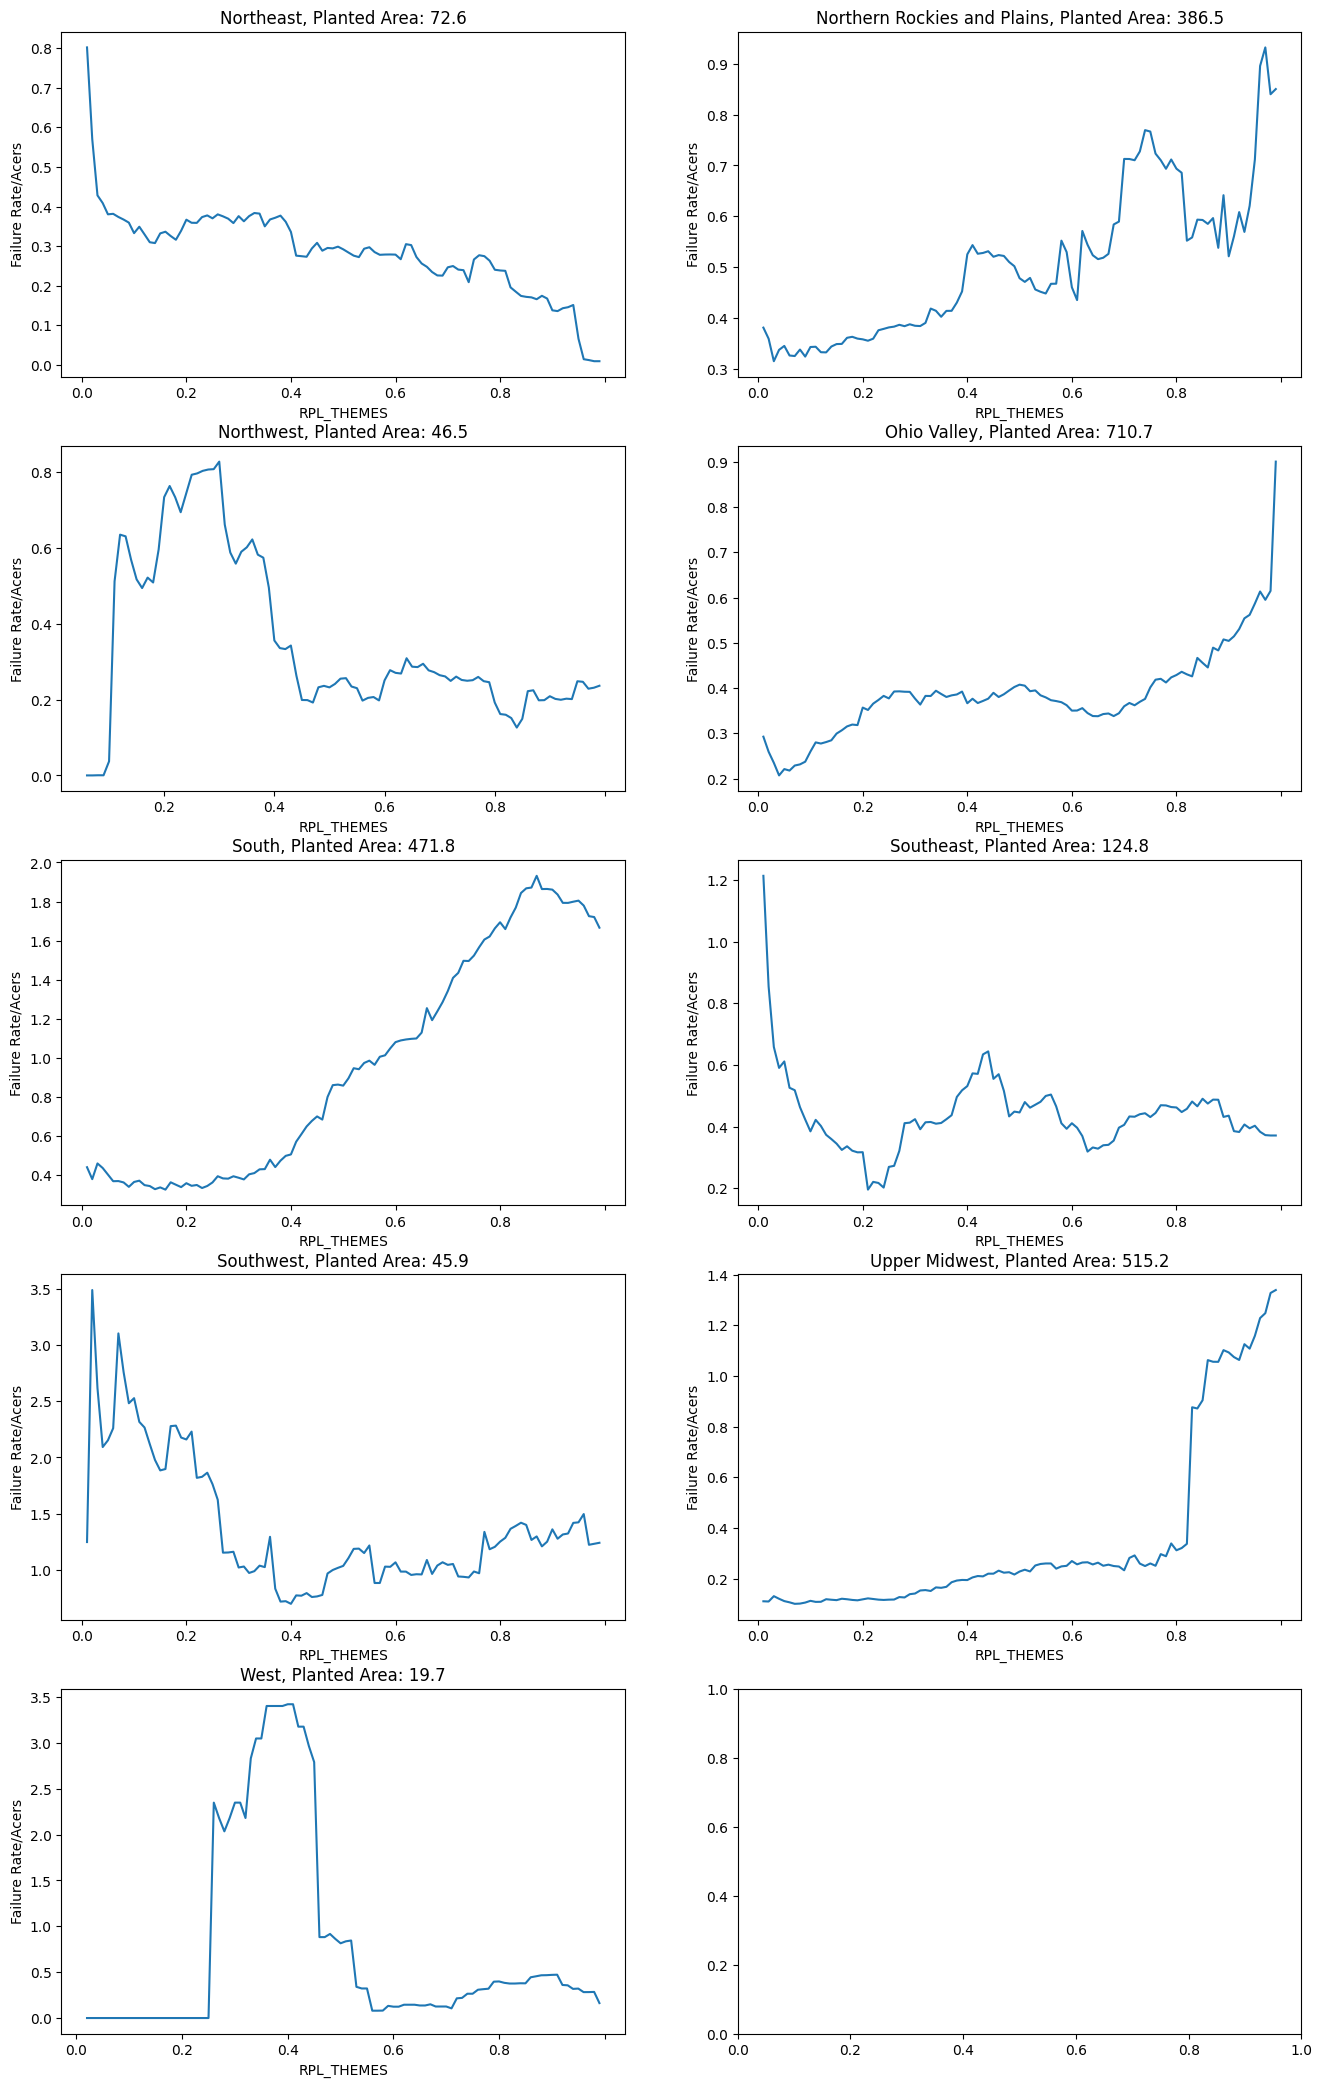

In [ ]:
df_merge = pd.merge(df_merge_clim,df_svi_cat,on=['FIPS','year'])
df_merge[df_merge.fail_share>0]['fail_share'] = 1
df_group = df_merge.groupby(['ClimRegNam','RPL_THEMES']).sum()[['Planted Acres','fail_share']]
df_group['fail_event_rate'] = df_group['fail_share'] / df_group['Planted Acres']
df_rate = df_group.fail_event_rate * 1e6
df_rate = df_rate.reset_index()
df_pivot = df_rate.pivot(index='RPL_THEMES',columns='ClimRegNam',values='fail_event_rate')
df_pivot

df_sump = df_group.reset_index().groupby('ClimRegNam').sum().reset_index()[['ClimRegNam','Planted Acres']]
df_sump = df_sump.set_index('ClimRegNam')

df_smoothed = df_pivot.rolling(window=20,min_periods=2).mean()
fig , axes = plt.subplots(5,2,figsize=(16,26))

for i , ax in enumerate(list(axes.flatten())):
  if i>8: break
  df_smoothed.iloc[:,i].plot(ax=ax)
  sump = df_sump.loc[list(df_pivot.columns)[i],'Planted Acres']
  ax.set_title(list(df_pivot.columns)[i]+ ', Planted Area: ' +f'{sump/1e6:.1f}')
  ax.set_ylabel('Failure Rate/Acers')


# ax.bar(df_sump['ClimRegNam'],df_sump['Planted Acres'])

In [ ]:
sump = df_sump.loc[list(df_pivot.columns)[8],'Planted Acres']
sump = sump/1e6

19.7096745726

'19.7'